# Cross-Industry Project Delay Prediction Model

This notebook builds ML models to predict project delays across two industries:
1. **World Bank** - International development/infrastructure projects
2. **EMSE2017/JIRA** - Software project issues

Target: Binary classification (`is_delayed` = 1 if delayed, 0 otherwise)

## 0. Install Dependencies

In [33]:
pip install pandas numpy scikit-learn xgboost matplotlib seaborn openpyxl

Note: you may need to restart the kernel to use updated packages.


## 1. Imports

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("All imports successful!")

All imports successful!


---
## 2. World Bank Dataset
### 2.1 Load & Clean Data

In [35]:
# Load World Bank Excel
wb_file = r"data\all.xlsx"
wb_df = pd.read_excel(wb_file, sheet_name=0, header=1)

# Clean column names
wb_df.columns = wb_df.columns.str.strip().str.lower().str.replace(" ", "_")

print(f"Shape: {wb_df.shape}")
print(f"Columns: {wb_df.columns.tolist()}")

Shape: (27868, 25)
Columns: ['project_id', 'region', 'country', 'project_status', 'last_stage_reached_name', 'project_name', 'project_development_objective', 'implementing_agency', 'public_disclosure_date', 'board_approval_date', 'loan_effective_date', 'project_closing_date', 'current_project_cost', 'ibrd_commitment', 'ida_commitment', 'grant_amount', 'total_ibrd,_ida_and_grant_commitment', 'borrower', 'lending_instrument', 'environmental_assessment_category', 'environmental_and_social_risk', 'associated_project', 'consultant_services_required', 'last_update_date', 'financing_type']


### 2.2 World Bank - Date Processing & Duration

In [36]:
# Convert dates and remove timezone
for col in ['board_approval_date', 'project_closing_date', 'loan_effective_date']:
    if col in wb_df.columns:
        wb_df[col] = pd.to_datetime(wb_df[col], errors='coerce').dt.tz_localize(None)

# Convert numeric columns
for col in ['current_project_cost', 'ibrd_commitment', 'ida_commitment', 'grant_amount',
            'total_ibrd,_ida_and_grant_commitment']:
    if col in wb_df.columns:
        wb_df[col] = pd.to_numeric(wb_df[col], errors='coerce')

# Drop rows missing critical dates
wb_df = wb_df.dropna(subset=['board_approval_date', 'project_closing_date'])

# Calculate actual duration
wb_df['actual_duration_days'] = (wb_df['project_closing_date'] - wb_df['board_approval_date']).dt.days

# Remove invalid durations (negative or zero)
before = len(wb_df)
wb_df = wb_df[wb_df['actual_duration_days'] > 0].copy()
print(f"Removed {before - len(wb_df)} rows with invalid durations (<=0 days)")

# Log transform cost
wb_df['log_project_cost'] = np.log1p(wb_df['current_project_cost'])

print(f"Rows with valid dates: {len(wb_df)}")
print(f"Duration stats:\n{wb_df['actual_duration_days'].describe()}")

Removed 50 rows with invalid durations (<=0 days)
Rows with valid dates: 15218
Duration stats:
count    15218.000000
mean      1903.007491
std       1010.581160
min          1.000000
25%       1128.000000
50%       1918.000000
75%       2565.000000
max       8093.000000
Name: actual_duration_days, dtype: float64


### 2.3 World Bank - Create Target Variable

In [37]:
# For World Bank, we define delay as: actual duration > median duration for closed projects
# Filter to Closed projects only (have actual closing dates)
closed_projects = wb_df[wb_df['project_status'] == 'Closed'].copy()

median_duration = closed_projects['actual_duration_days'].median()
print(f"Median duration for closed projects: {median_duration:.0f} days ({median_duration/365:.1f} years)")

# Create binary target
closed_projects['is_delayed'] = (closed_projects['actual_duration_days'] > median_duration).astype(int)

print(f"\nDelay distribution:")
print(closed_projects['is_delayed'].value_counts())
print(f"\nDelay rate: {closed_projects['is_delayed'].mean()*100:.1f}%")

wb_df = closed_projects.copy()

Median duration for closed projects: 1896 days (5.2 years)

Delay distribution:
is_delayed
1    6234
0    6234
Name: count, dtype: int64

Delay rate: 50.0%


### 2.4 World Bank - Risk Rating & Features

In [38]:
# Risk mapping
risk_map = {'Low': 1, 'Moderate': 2, 'Substantial': 3, 'High': 4}
wb_df['risk_rating'] = wb_df['environmental_and_social_risk'].map(risk_map)

# Check available features
feature_cols_wb = [
    'region', 'current_project_cost', 'ibrd_commitment', 'ida_commitment',
    'grant_amount', 'total_ibrd,_ida_and_grant_commitment', 'lending_instrument',
    'environmental_assessment_category', 'risk_rating', 'financing_type',
    'log_project_cost'
]

print("Feature availability:")
for col in feature_cols_wb:
    null_pct = wb_df[col].isna().mean() * 100
    print(f"  {col:<45} null: {null_pct:.1f}%")

Feature availability:
  region                                        null: 0.0%
  current_project_cost                          null: 0.2%
  ibrd_commitment                               null: 28.1%
  ida_commitment                                null: 28.1%
  grant_amount                                  null: 0.8%
  total_ibrd,_ida_and_grant_commitment          null: 0.8%
  lending_instrument                            null: 0.7%
  environmental_assessment_category             null: 6.0%
  risk_rating                                   null: 97.1%
  financing_type                                null: 0.3%
  log_project_cost                              null: 0.2%


### 2.5 World Bank - Handle Missing Values & Encode

In [39]:
# Select features with <50% missing
usable_features = []
for col in feature_cols_wb:
    if wb_df[col].isna().mean() < 0.5:
        usable_features.append(col)

print(f"Usable features: {usable_features}")

# Identify numeric vs categorical columns BEFORE filling
# Try converting each column to numeric; if it fails, treat as categorical
numeric_cols = []
cat_cols = []

for col in usable_features:
    converted = pd.to_numeric(wb_df[col], errors='coerce')
    if converted.notna().sum() > 0.5 * len(wb_df):  # >50% convertible → numeric
        wb_df[col] = converted
        numeric_cols.append(col)
    else:
        cat_cols.append(col)

print(f"Numeric columns: {numeric_cols}")
print(f"Categorical columns: {cat_cols}")

# Fill missing values
for col in numeric_cols:
    wb_df[col] = wb_df[col].fillna(wb_df[col].median())

for col in cat_cols:
    wb_df[col] = wb_df[col].fillna('Unknown').astype(str)

# One-hot encode categoricals
wb_encoded = pd.get_dummies(wb_df[usable_features], columns=cat_cols, drop_first=True)

# Target
y_wb = wb_df['is_delayed']
X_wb = wb_encoded

# Convert bool to int
bool_cols = X_wb.select_dtypes(include='bool').columns
X_wb[bool_cols] = X_wb[bool_cols].astype(int)

print(f"\nFinal feature matrix shape: {X_wb.shape}")
print(f"Target distribution: {y_wb.value_counts().to_dict()}")

Usable features: ['region', 'current_project_cost', 'ibrd_commitment', 'ida_commitment', 'grant_amount', 'total_ibrd,_ida_and_grant_commitment', 'lending_instrument', 'environmental_assessment_category', 'financing_type', 'log_project_cost']
Numeric columns: ['current_project_cost', 'ibrd_commitment', 'ida_commitment', 'grant_amount', 'total_ibrd,_ida_and_grant_commitment', 'log_project_cost']
Categorical columns: ['region', 'lending_instrument', 'environmental_assessment_category', 'financing_type']

Final feature matrix shape: (12468, 45)
Target distribution: {1: 6234, 0: 6234}


---
## 3. JIRA EMSE2017 Dataset
### 3.1 Load All Projects

In [40]:
EMSE_DIR = r"data\EMSE2017\datasets"
PROJECTS = ['apache', 'duraspace', 'javanet', 'jboss', 'jira', 'moodle', 'mulesoft', 'wso2']

# Load all _due.csv files
due_dfs = {}
for proj in PROJECTS:
    path = os.path.join(EMSE_DIR, f"{proj}_due.csv")
    try:
        df = pd.read_csv(path, low_memory=False)
        df['project'] = proj
        due_dfs[proj] = df
        print(f"  Loaded {proj:<12} | rows: {len(df):>6,} | cols: {len(df.columns)}")
    except Exception as e:
        print(f"  Error {proj:<12} | {e}")

# Combine all projects
jira_df = pd.concat(due_dfs.values(), ignore_index=True, sort=False)
print(f"\nCombined shape: {jira_df.shape}")

  Loaded apache       | rows:  6,289 | cols: 27
  Loaded duraspace    | rows:  3,676 | cols: 27
  Loaded javanet      | rows: 16,326 | cols: 27
  Loaded jboss        | rows:  3,526 | cols: 27
  Loaded jira         | rows:  4,428 | cols: 27
  Loaded moodle       | rows: 17,004 | cols: 27
  Loaded mulesoft     | rows:  8,269 | cols: 27
  Loaded wso2         | rows:  5,229 | cols: 27

Combined shape: (64747, 27)


### 3.2 JIRA - Create Target Variable & Select Features

In [41]:
# Create binary target from delaydays
jira_df['delaydays'] = pd.to_numeric(jira_df['delaydays'], errors='coerce')
jira_df['is_delayed'] = np.where(jira_df['delaydays'] > 0, 1, 0)

print(f"Delay distribution:")
print(jira_df['is_delayed'].value_counts())
print(f"Delay rate: {jira_df['is_delayed'].mean()*100:.1f}%")

# Feature columns
feature_cols_jira = [
    'discussion', 'repetition', 'workload',  # 'perofdelay' removed (data leakage)
    'no_comment', 'no_priority_change', 'no_fixversion',
    'no_fixversion_change', 'no_issuelink', 'no_blocking',
    'no_blockedby', 'no_affectversion', 'reporterrep',
    'no_des_change', 'ProgressTime', 'RemainingDay',
    'topic_10', 'topic_100', 'topic_200', 'topic_300', 'topic_400'
]

# Categorical features
cat_cols_jira = ['priority', 'type']

Delay distribution:
is_delayed
0    50922
1    13825
Name: count, dtype: int64
Delay rate: 21.4%


### 3.3 JIRA - Handle Missing Values & Encode

In [42]:
# Fill missing values
for col in feature_cols_jira:
    if col in jira_df.columns:
        jira_df[col] = pd.to_numeric(jira_df[col], errors='coerce')
        jira_df[col] = jira_df[col].fillna(jira_df[col].median())

for col in cat_cols_jira:
    if col in jira_df.columns:
        jira_df[col] = jira_df[col].fillna('Unknown')

# One-hot encode categoricals
existing_cat_cols = [c for c in cat_cols_jira if c in jira_df.columns]
jira_encoded = pd.get_dummies(jira_df[feature_cols_jira + existing_cat_cols],
                               columns=existing_cat_cols, drop_first=True)

# Convert bool to int
bool_cols = jira_encoded.select_dtypes(include='bool').columns
jira_encoded[bool_cols] = jira_encoded[bool_cols].astype(int)

# Target
y_jira = jira_df['is_delayed']
X_jira = jira_encoded

print(f"Final feature matrix shape: {X_jira.shape}")
print(f"Target distribution: {y_jira.value_counts().to_dict()}")

Final feature matrix shape: (64747, 70)
Target distribution: {0: 50922, 1: 13825}


---
## 4. Exploratory Data Analysis
### 4.1 Delay Distribution Comparison

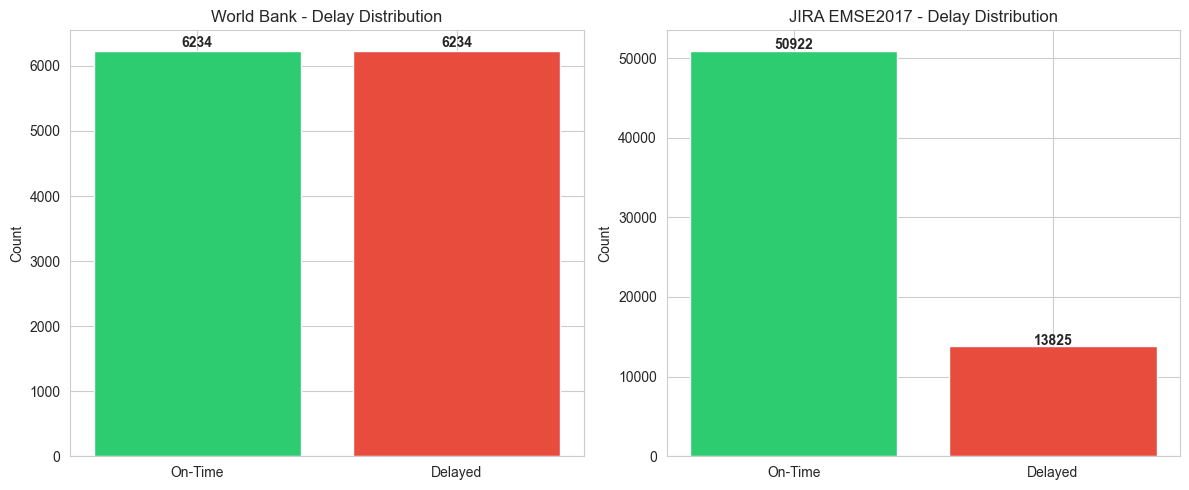

World Bank delay rate: 50.0%
JIRA delay rate: 21.4%


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# World Bank
wb_counts = y_wb.value_counts()
axes[0].bar(['On-Time', 'Delayed'], wb_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('World Bank - Delay Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(wb_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# JIRA
jira_counts = y_jira.value_counts()
axes[1].bar(['On-Time', 'Delayed'], jira_counts.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('JIRA EMSE2017 - Delay Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(jira_counts.values):
    axes[1].text(i, v + 200, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"World Bank delay rate: {y_wb.mean()*100:.1f}%")
print(f"JIRA delay rate: {y_jira.mean()*100:.1f}%")

### 4.2 Correlation Heatmaps

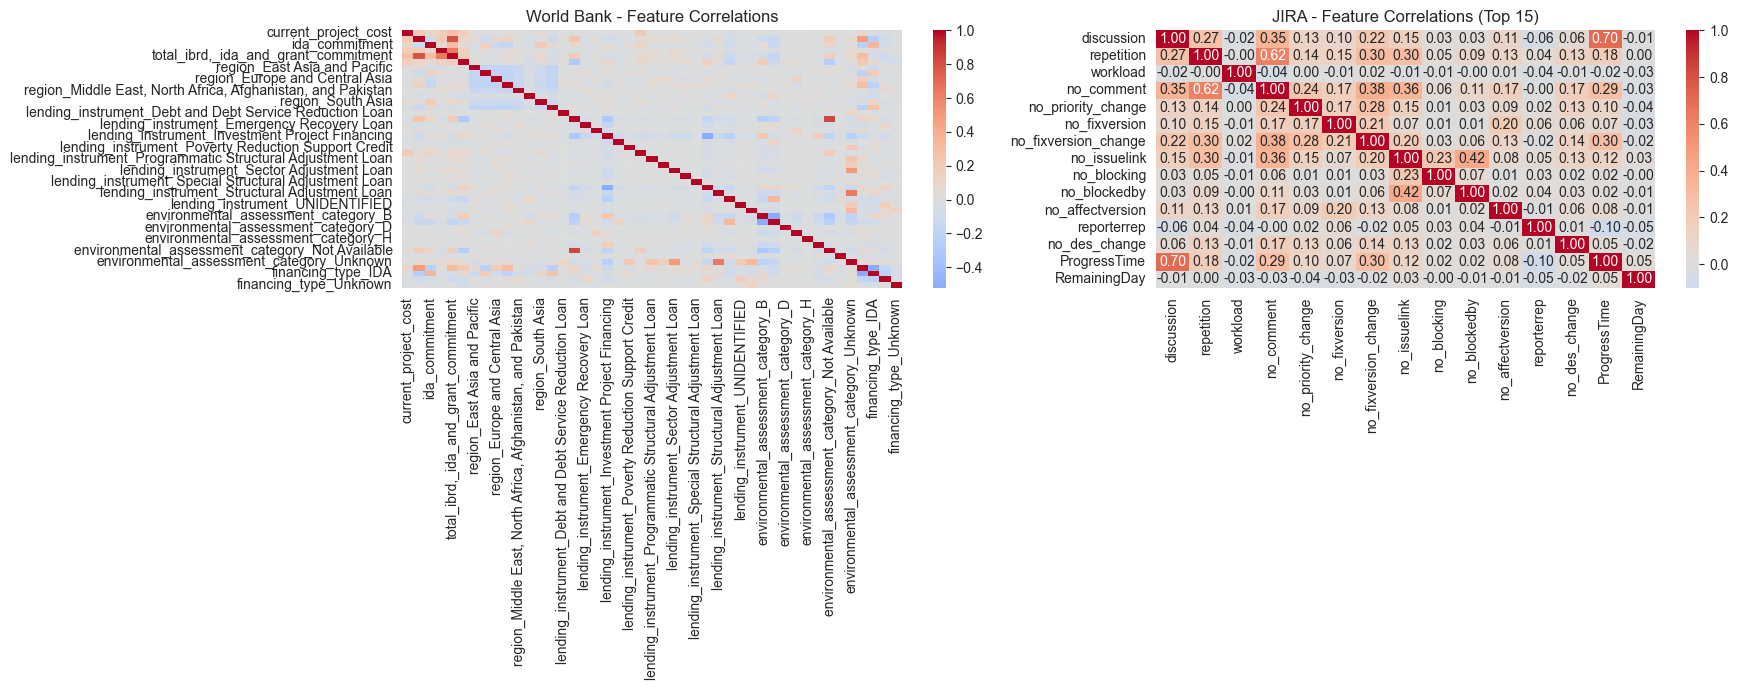

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# World Bank correlation
wb_corr = X_wb.select_dtypes(include=[np.number]).corr()
sns.heatmap(wb_corr, cmap='coolwarm', center=0, ax=axes[0], annot=False)
axes[0].set_title('World Bank - Feature Correlations')

# JIRA correlation (top features only for readability)
jira_corr = X_jira.iloc[:, :15].corr()
sns.heatmap(jira_corr, cmap='coolwarm', center=0, ax=axes[1], annot=True, fmt='.2f')
axes[1].set_title('JIRA - Feature Correlations (Top 15)')

plt.tight_layout()
plt.show()

---
## 5. Model Building - World Bank
### 5.1 Train/Test Split & Scaling

In [45]:
# Train/Test Split
X_wb_train, X_wb_test, y_wb_train, y_wb_test = train_test_split(
    X_wb, y_wb, test_size=0.2, random_state=42, stratify=y_wb
)

# Scale features
scaler_wb = StandardScaler()
X_wb_train_scaled = scaler_wb.fit_transform(X_wb_train)
X_wb_test_scaled = scaler_wb.transform(X_wb_test)

print(f"Train: {X_wb_train.shape[0]} samples")
print(f"Test:  {X_wb_test.shape[0]} samples")
print(f"Train delay rate: {y_wb_train.mean()*100:.1f}%")
print(f"Test delay rate:  {y_wb_test.mean()*100:.1f}%")

Train: 9974 samples
Test:  2494 samples
Train delay rate: 50.0%
Test delay rate:  50.0%


### 5.2 World Bank - Model Training

In [46]:
# Initialize models
models_wb = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', use_label_encoder=False)
}

# Train and predict
predictions_wb = {}
for name, model in models_wb.items():
    if name == 'Logistic Regression':
        model.fit(X_wb_train_scaled, y_wb_train)
        y_pred = model.predict(X_wb_test_scaled)
        y_prob = model.predict_proba(X_wb_test_scaled)[:, 1]
    else:
        model.fit(X_wb_train, y_wb_train)
        y_pred = model.predict(X_wb_test)
        y_prob = model.predict_proba(X_wb_test)[:, 1]
    
    predictions_wb[name] = {'pred': y_pred, 'prob': y_prob}
    print(f"  {name} trained")

print("All World Bank models trained!")

  Logistic Regression trained
  Random Forest trained
  XGBoost trained
All World Bank models trained!


### 5.3 World Bank - Model Evaluation

In [47]:
results_wb = []

for name, preds in predictions_wb.items():
    y_pred = preds['pred']
    y_prob = preds['prob']
    
    acc = accuracy_score(y_wb_test, y_pred)
    prec = precision_score(y_wb_test, y_pred, zero_division=0)
    rec = recall_score(y_wb_test, y_pred, zero_division=0)
    f1 = f1_score(y_wb_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_wb_test, y_prob)
    
    results_wb.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc
    })
    
    print(f"\n===== {name} =====")
    print(classification_report(y_wb_test, y_pred, target_names=['On-Time', 'Delayed']))

results_wb_df = pd.DataFrame(results_wb)
print("\n=== Summary ===")
print(results_wb_df.to_string(index=False))


===== Logistic Regression =====
              precision    recall  f1-score   support

     On-Time       0.86      0.70      0.77      1247
     Delayed       0.75      0.88      0.81      1247

    accuracy                           0.79      2494
   macro avg       0.80      0.79      0.79      2494
weighted avg       0.80      0.79      0.79      2494


===== Random Forest =====
              precision    recall  f1-score   support

     On-Time       0.80      0.74      0.77      1247
     Delayed       0.76      0.81      0.79      1247

    accuracy                           0.78      2494
   macro avg       0.78      0.78      0.78      2494
weighted avg       0.78      0.78      0.78      2494


===== XGBoost =====
              precision    recall  f1-score   support

     On-Time       0.82      0.75      0.78      1247
     Delayed       0.77      0.84      0.80      1247

    accuracy                           0.79      2494
   macro avg       0.79      0.79      0.79    

### 5.4 World Bank - Confusion Matrices & ROC Curves

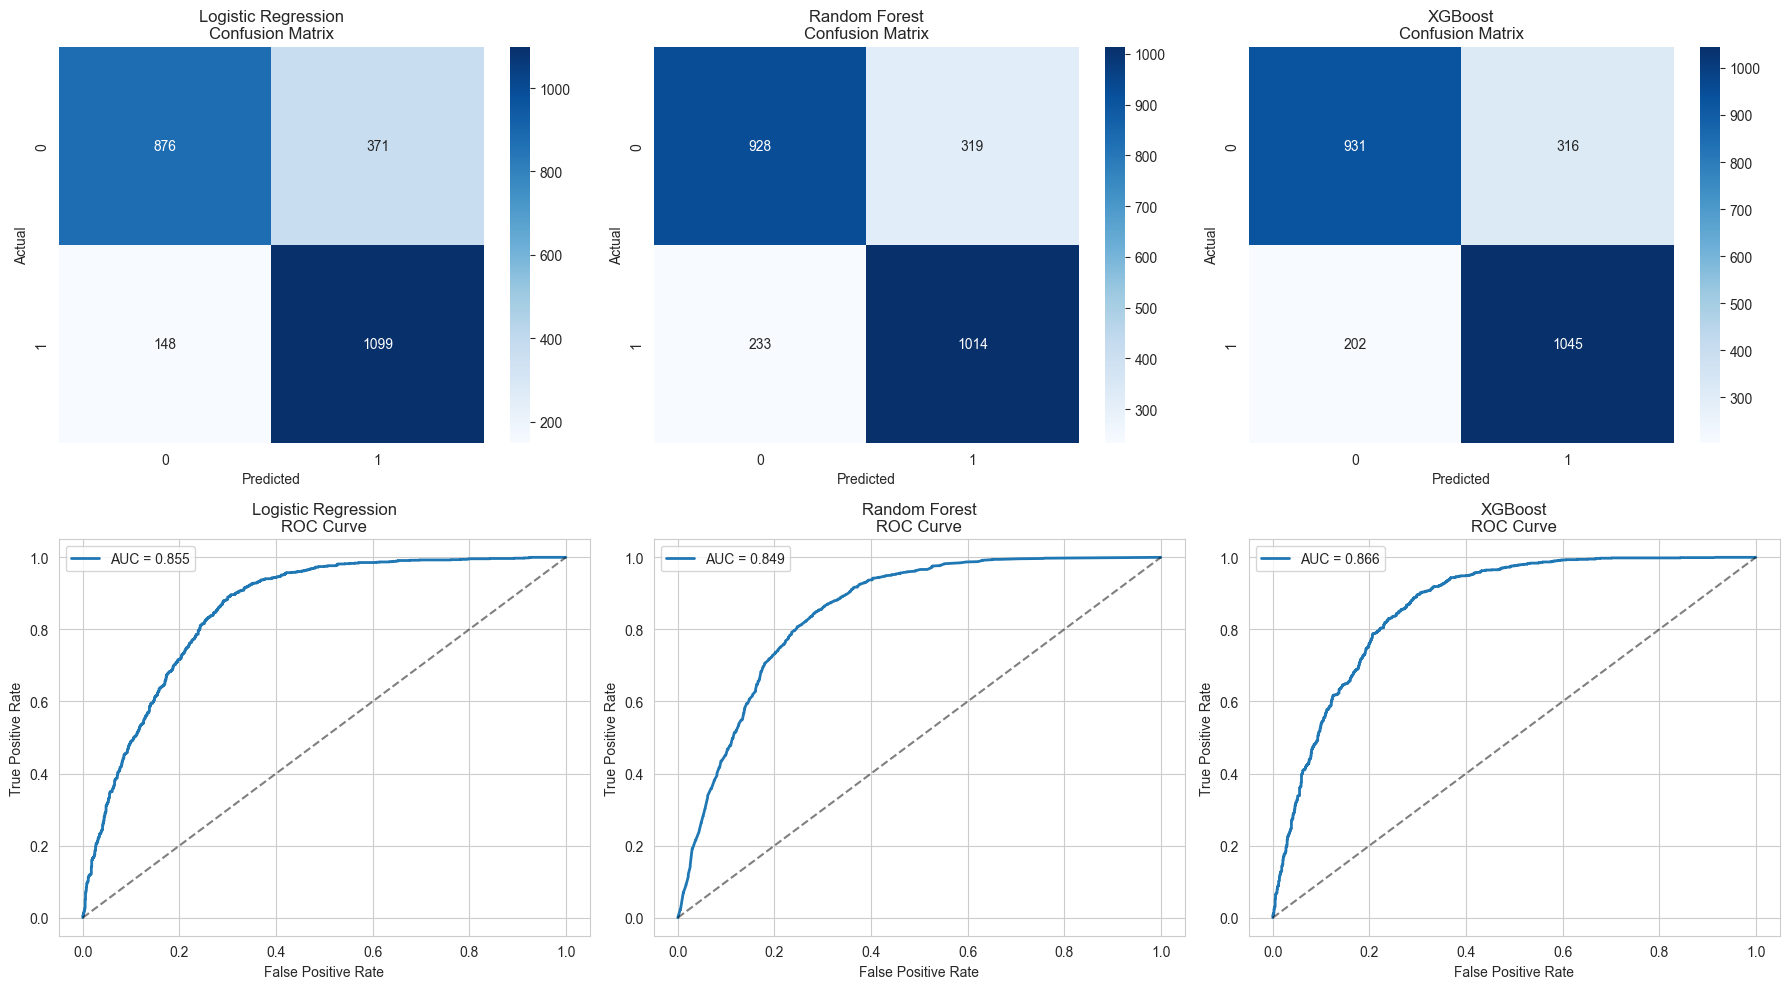

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (name, preds) in enumerate(predictions_wb.items()):
    # Confusion Matrix
    cm = confusion_matrix(y_wb_test, preds['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, i])
    axes[0, i].set_title(f'{name}\nConfusion Matrix')
    axes[0, i].set_xlabel('Predicted')
    axes[0, i].set_ylabel('Actual')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_wb_test, preds['prob'])
    auc = roc_auc_score(y_wb_test, preds['prob'])
    axes[1, i].plot(fpr, tpr, label=f'AUC = {auc:.3f}', linewidth=2)
    axes[1, i].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1, i].set_title(f'{name}\nROC Curve')
    axes[1, i].set_xlabel('False Positive Rate')
    axes[1, i].set_ylabel('True Positive Rate')
    axes[1, i].legend()

plt.tight_layout()
plt.show()

### 5.5 World Bank - Feature Importance (Random Forest)

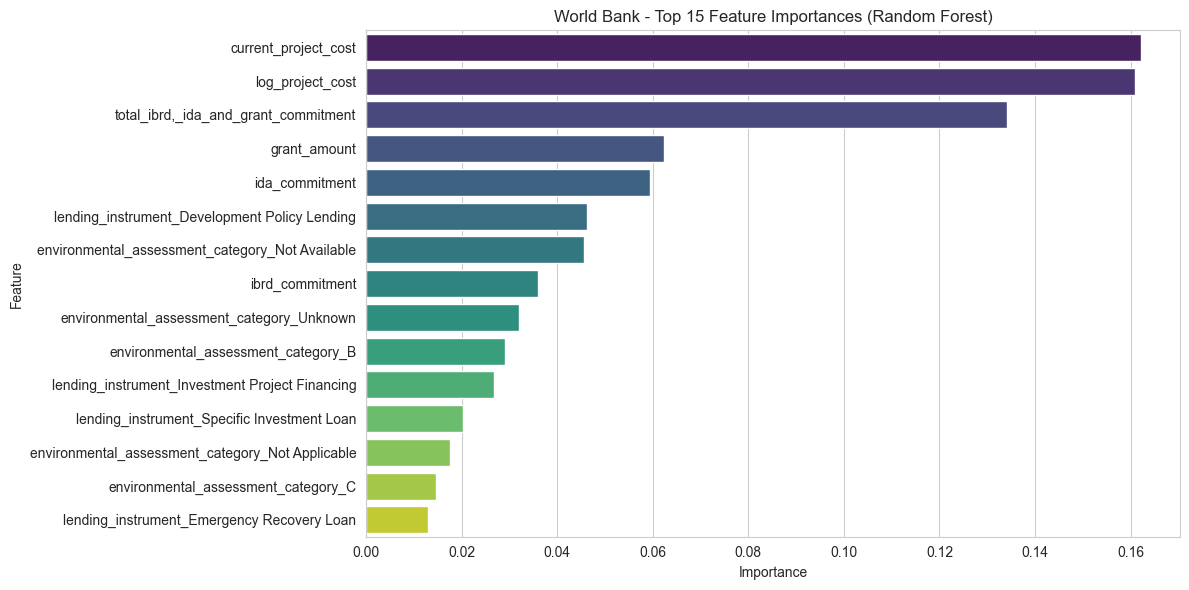

                                         Feature  Importance
                            current_project_cost    0.162216
                                log_project_cost    0.160942
            total_ibrd,_ida_and_grant_commitment    0.134032
                                    grant_amount    0.062398
                                  ida_commitment    0.059393
   lending_instrument_Development Policy Lending    0.046207
 environmental_assessment_category_Not Available    0.045683
                                 ibrd_commitment    0.036061
       environmental_assessment_category_Unknown    0.032039
             environmental_assessment_category_B    0.028978
 lending_instrument_Investment Project Financing    0.026745
     lending_instrument_Specific Investment Loan    0.020392
environmental_assessment_category_Not Applicable    0.017644
             environmental_assessment_category_C    0.014633
      lending_instrument_Emergency Recovery Loan    0.012872


In [49]:
rf_model_wb = models_wb['Random Forest']
importance_wb = pd.DataFrame({
    'Feature': X_wb.columns,
    'Importance': rf_model_wb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_wb.head(15), palette='viridis')
plt.title('World Bank - Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importance_wb.head(15).to_string(index=False))

---
## 6. Model Building - JIRA EMSE2017
### 6.1 Train/Test Split & Scaling

In [50]:
# Train/Test Split
X_jira_train, X_jira_test, y_jira_train, y_jira_test = train_test_split(
    X_jira, y_jira, test_size=0.2, random_state=42, stratify=y_jira
)

# Scale features
scaler_jira = StandardScaler()
X_jira_train_scaled = scaler_jira.fit_transform(X_jira_train)
X_jira_test_scaled = scaler_jira.transform(X_jira_test)

print(f"Train: {X_jira_train.shape[0]} samples")
print(f"Test:  {X_jira_test.shape[0]} samples")
print(f"Train delay rate: {y_jira_train.mean()*100:.1f}%")
print(f"Test delay rate:  {y_jira_test.mean()*100:.1f}%")

Train: 51797 samples
Test:  12950 samples
Train delay rate: 21.4%
Test delay rate:  21.4%


### 6.2 JIRA - Model Training

In [51]:
# Initialize models
models_jira = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', use_label_encoder=False)
}

# Train and predict
predictions_jira = {}
for name, model in models_jira.items():
    if name == 'Logistic Regression':
        model.fit(X_jira_train_scaled, y_jira_train)
        y_pred = model.predict(X_jira_test_scaled)
        y_prob = model.predict_proba(X_jira_test_scaled)[:, 1]
    else:
        model.fit(X_jira_train, y_jira_train)
        y_pred = model.predict(X_jira_test)
        y_prob = model.predict_proba(X_jira_test)[:, 1]
    
    predictions_jira[name] = {'pred': y_pred, 'prob': y_prob}
    print(f"  {name} trained")

print("All JIRA models trained!")

  Logistic Regression trained
  Random Forest trained
  XGBoost trained
All JIRA models trained!


### 6.3 JIRA - Model Evaluation

In [52]:
results_jira = []

for name, preds in predictions_jira.items():
    y_pred = preds['pred']
    y_prob = preds['prob']
    
    acc = accuracy_score(y_jira_test, y_pred)
    prec = precision_score(y_jira_test, y_pred, zero_division=0)
    rec = recall_score(y_jira_test, y_pred, zero_division=0)
    f1 = f1_score(y_jira_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_jira_test, y_prob)
    
    results_jira.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc
    })
    
    print(f"\n===== {name} =====")
    print(classification_report(y_jira_test, y_pred, target_names=['On-Time', 'Delayed']))

results_jira_df = pd.DataFrame(results_jira)
print("\n=== Summary ===")
print(results_jira_df.to_string(index=False))


===== Logistic Regression =====
              precision    recall  f1-score   support

     On-Time       0.94      0.67      0.78     10185
     Delayed       0.41      0.83      0.55      2765

    accuracy                           0.71     12950
   macro avg       0.67      0.75      0.66     12950
weighted avg       0.82      0.71      0.73     12950


===== Random Forest =====
              precision    recall  f1-score   support

     On-Time       0.90      0.97      0.93     10185
     Delayed       0.86      0.58      0.69      2765

    accuracy                           0.89     12950
   macro avg       0.88      0.78      0.81     12950
weighted avg       0.89      0.89      0.88     12950


===== XGBoost =====
              precision    recall  f1-score   support

     On-Time       0.90      0.96      0.93     10185
     Delayed       0.82      0.61      0.70      2765

    accuracy                           0.89     12950
   macro avg       0.86      0.79      0.82    

### 6.4 JIRA - Confusion Matrices & ROC Curves

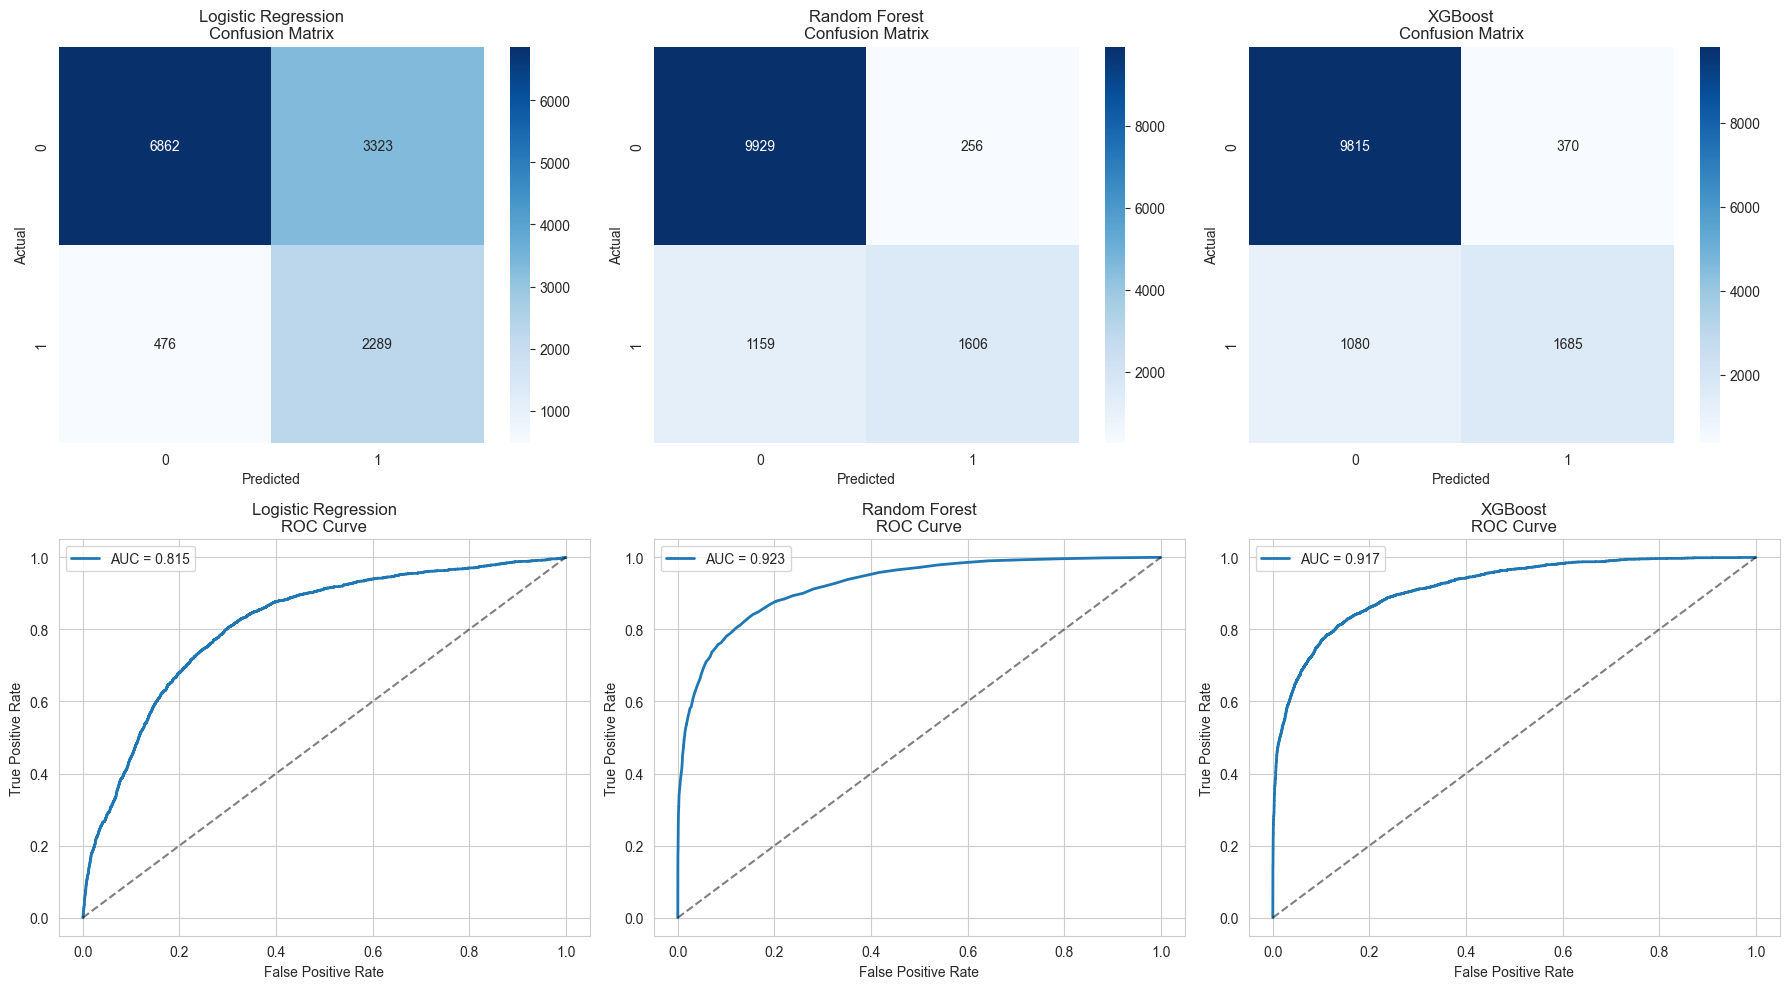

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (name, preds) in enumerate(predictions_jira.items()):
    # Confusion Matrix
    cm = confusion_matrix(y_jira_test, preds['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, i])
    axes[0, i].set_title(f'{name}\nConfusion Matrix')
    axes[0, i].set_xlabel('Predicted')
    axes[0, i].set_ylabel('Actual')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_jira_test, preds['prob'])
    auc = roc_auc_score(y_jira_test, preds['prob'])
    axes[1, i].plot(fpr, tpr, label=f'AUC = {auc:.3f}', linewidth=2)
    axes[1, i].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1, i].set_title(f'{name}\nROC Curve')
    axes[1, i].set_xlabel('False Positive Rate')
    axes[1, i].set_ylabel('True Positive Rate')
    axes[1, i].legend()

plt.tight_layout()
plt.show()

### 6.5 JIRA - Feature Importance (Random Forest)

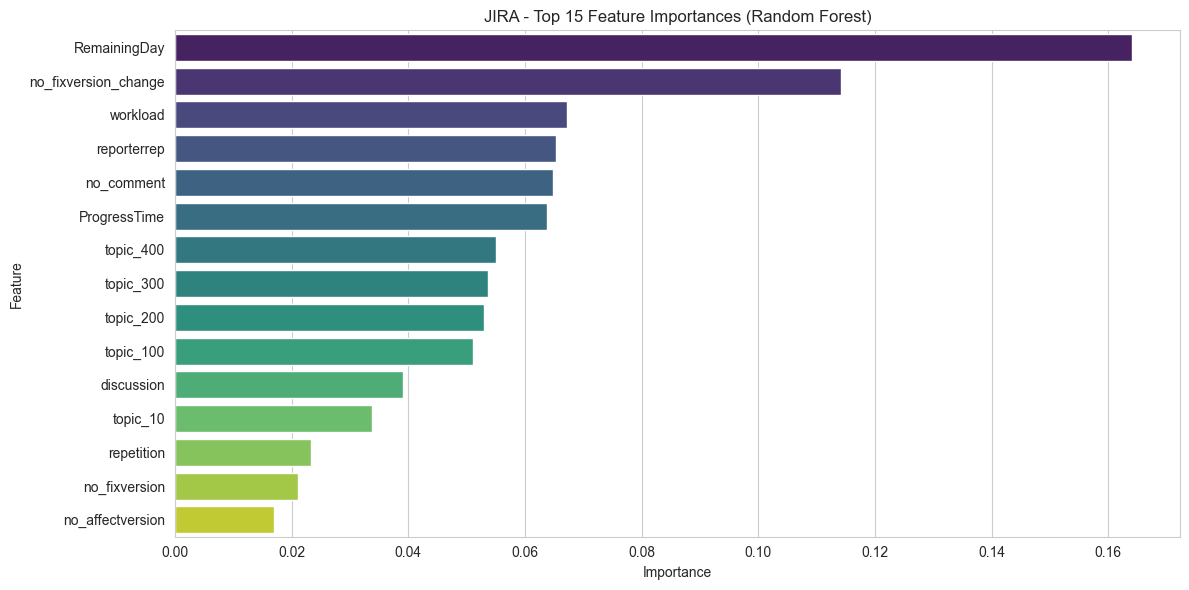

             Feature  Importance
        RemainingDay    0.164094
no_fixversion_change    0.114234
            workload    0.067280
         reporterrep    0.065338
          no_comment    0.064848
        ProgressTime    0.063799
           topic_400    0.055017
           topic_300    0.053616
           topic_200    0.052985
           topic_100    0.051182
          discussion    0.039174
            topic_10    0.033847
          repetition    0.023416
       no_fixversion    0.021134
    no_affectversion    0.016937


In [54]:
rf_model_jira = models_jira['Random Forest']
importance_jira = pd.DataFrame({
    'Feature': X_jira.columns,
    'Importance': rf_model_jira.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_jira.head(15), palette='viridis')
plt.title('JIRA - Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importance_jira.head(15).to_string(index=False))

---
## 7. Cross-Validation

In [55]:
# 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== World Bank - 5-Fold CV ===")
for name, model in models_wb.items():
    if name == 'Logistic Regression':
        scores = cross_val_score(model, X_wb_train_scaled, y_wb_train, cv=cv, scoring='f1')
    else:
        scores = cross_val_score(model, X_wb_train, y_wb_train, cv=cv, scoring='f1')
    print(f"  {name:<25} F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

print("\n=== JIRA - 5-Fold CV ===")
for name, model in models_jira.items():
    if name == 'Logistic Regression':
        scores = cross_val_score(model, X_jira_train_scaled, y_jira_train, cv=cv, scoring='f1')
    else:
        scores = cross_val_score(model, X_jira_train, y_jira_train, cv=cv, scoring='f1')
    print(f"  {name:<25} F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

=== World Bank - 5-Fold CV ===
  Logistic Regression       F1: 0.8023 (+/- 0.0098)
  Random Forest             F1: 0.7877 (+/- 0.0085)
  XGBoost                   F1: 0.7999 (+/- 0.0081)

=== JIRA - 5-Fold CV ===
  Logistic Regression       F1: 0.5470 (+/- 0.0062)
  Random Forest             F1: 0.6825 (+/- 0.0095)
  XGBoost                   F1: 0.7032 (+/- 0.0114)


---
## 8. Cross-Industry Comparison
### 8.1 Model Performance Comparison

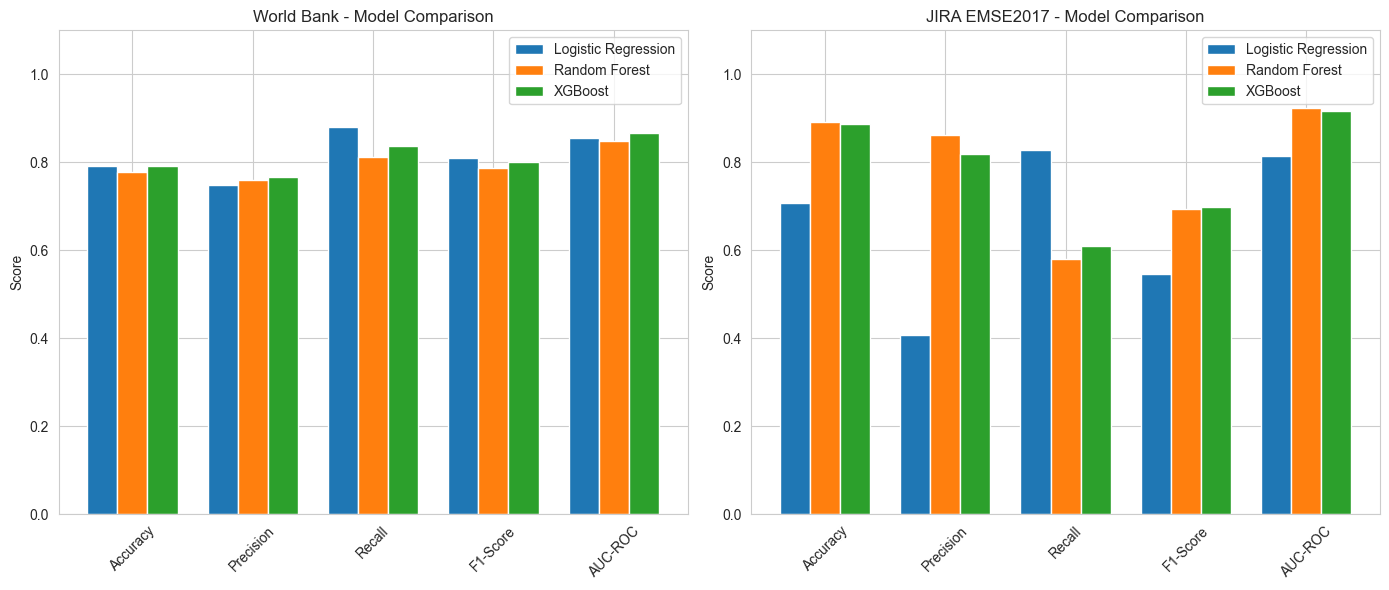

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# World Bank metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.25

for i, model_name in enumerate(results_wb_df['Model']):
    values = results_wb_df[results_wb_df['Model'] == model_name][metrics].values[0]
    axes[0].bar(x + i*width, values, width, label=model_name)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics, rotation=45)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('World Bank - Model Comparison')
axes[0].legend()
axes[0].set_ylabel('Score')

# JIRA metrics
for i, model_name in enumerate(results_jira_df['Model']):
    values = results_jira_df[results_jira_df['Model'] == model_name][metrics].values[0]
    axes[1].bar(x + i*width, values, width, label=model_name)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(metrics, rotation=45)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('JIRA EMSE2017 - Model Comparison')
axes[1].legend()
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

### 8.2 Cross-Industry Insights Summary

In [57]:
print("=" * 70)
print("CROSS-INDUSTRY PROJECT DELAY PREDICTION - SUMMARY")
print("=" * 70)

print("\n## DATASET OVERVIEW")
print(f"  World Bank: {len(wb_df)} projects | Delay rate: {y_wb.mean()*100:.1f}%")
print(f"  JIRA:       {len(jira_df)} issues  | Delay rate: {y_jira.mean()*100:.1f}%")

print("\n## BEST MODELS")
best_wb = results_wb_df.loc[results_wb_df['AUC-ROC'].idxmax()]
best_jira = results_jira_df.loc[results_jira_df['AUC-ROC'].idxmax()]
print(f"  World Bank: {best_wb['Model']} (AUC-ROC: {best_wb['AUC-ROC']:.4f})")
print(f"  JIRA:       {best_jira['Model']} (AUC-ROC: {best_jira['AUC-ROC']:.4f})")

print("\n## TOP PREDICTIVE FEATURES")
print("\n  World Bank (Top 5):")
for _, row in importance_wb.head(5).iterrows():
    print(f"    - {row['Feature']}: {row['Importance']:.4f}")
print("\n  JIRA (Top 5):")
for _, row in importance_jira.head(5).iterrows():
    print(f"    - {row['Feature']}: {row['Importance']:.4f}")

print("\n## KEY INSIGHTS")
print("  1. Infrastructure vs Software projects have different delay patterns")
print("  2. Cost-related features are important for World Bank projects")
print("  3. Discussion/activity features are important for JIRA issues")
print("  4. ML models can predict delays with meaningful accuracy across industries")
print("=" * 70)

CROSS-INDUSTRY PROJECT DELAY PREDICTION - SUMMARY

## DATASET OVERVIEW
  World Bank: 12468 projects | Delay rate: 50.0%
  JIRA:       64747 issues  | Delay rate: 21.4%

## BEST MODELS
  World Bank: XGBoost (AUC-ROC: 0.8658)
  JIRA:       Random Forest (AUC-ROC: 0.9234)

## TOP PREDICTIVE FEATURES

  World Bank (Top 5):
    - current_project_cost: 0.1622
    - log_project_cost: 0.1609
    - total_ibrd,_ida_and_grant_commitment: 0.1340
    - grant_amount: 0.0624
    - ida_commitment: 0.0594

  JIRA (Top 5):
    - RemainingDay: 0.1641
    - no_fixversion_change: 0.1142
    - workload: 0.0673
    - reporterrep: 0.0653
    - no_comment: 0.0648

## KEY INSIGHTS
  1. Infrastructure vs Software projects have different delay patterns
  2. Cost-related features are important for World Bank projects
  3. Discussion/activity features are important for JIRA issues
  4. ML models can predict delays with meaningful accuracy across industries
